In [1]:
!pip install openml

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openml
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import seaborn as sns


from sklearn.model_selection import StratifiedKFold, train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from sklearn import svm
import optuna
from optuna.samplers import TPESampler
from scipy.stats import wilcoxon
from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats
import statsmodels.api as sm
from sklearn.feature_selection import VarianceThreshold
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from scipy.stats import t
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import f_classif

from sklearn.metrics import roc_curve, auc
import copy
from sklearn.metrics import confusion_matrix

In [3]:
# https://www.openml.org/search?type=data&status=active&id=43611
# Breast Cancer
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.neighbors import KNeighborsClassifier

dataset = openml.datasets.get_dataset(43611)

X, y, _, attribute_names = dataset.get_data(target=dataset.default_target_attribute)

# Połączenie cech i etykiety w jeden DataFrame (opcjonalnie)
data = pd.concat([X, y], axis=1)

# Podgląd pierwszych wierszy
print(data.head())

print(len(data))

np.unique(list(data['class']),return_counts=True)

        id  thickness  size  shape  adhesion  single  nuclei  chromatin  \
0  1000025          5     1      1         1       2     1.0          3   
1  1002945          5     4      4         5       7    10.0          3   
2  1015425          3     1      1         1       2     2.0          3   
3  1016277          6     8      8         1       3     4.0          3   
4  1017023          4     1      1         3       2     1.0          3   

   nucleoli  mitosis  class  
0         1        1      0  
1         2        1      0  
2         1        1      0  
3         7        1      0  
4         1        1      0  
699


(array([0, 1]), array([458, 241]))

In [4]:
data.dropna(inplace=True)
data = data.reset_index(drop=True)
y = data["class"]
X = data.iloc[:, 1:10]

print(X)

     thickness  size  shape  adhesion  single  nuclei  chromatin  nucleoli  \
0            5     1      1         1       2     1.0          3         1   
1            5     4      4         5       7    10.0          3         2   
2            3     1      1         1       2     2.0          3         1   
3            6     8      8         1       3     4.0          3         7   
4            4     1      1         3       2     1.0          3         1   
..         ...   ...    ...       ...     ...     ...        ...       ...   
678          3     1      1         1       3     2.0          1         1   
679          2     1      1         1       2     1.0          1         1   
680          5    10     10         3       7     3.0          8        10   
681          4     8      6         4       3     4.0         10         6   
682          4     8      8         5       4     5.0         10         4   

     mitosis  
0          1  
1          1  
2          1  
3  

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)
cv = KFold(n_splits = 5, shuffle=True, random_state=42)

n_feat_total = X_train.shape[1]
X_train

,thickness,size,shape,adhesion,single,nuclei,chromatin,nucleoli,mitosis
437,3,1,1,3,2,1.0,1,1,1
256,7,9,4,10,10,3.0,5,3,3
584,5,2,4,1,1,1.0,1,1,1
18,10,7,7,6,4,10.0,4,1,2
350,2,1,1,1,2,1.0,3,1,1
...,...,...,...,...,...,...,...,...,...
71,9,4,5,10,6,10.0,4,8,1
106,1,1,1,1,2,1.0,2,3,1
270,10,5,7,3,3,7.0,3,3,8
435,4,1,1,3,1,1.0,2,1,1


In [6]:
all_trial_scores = []

def objective(trial):
    # hiperparametry potrzebne w zadaniu
    
    n_features = trial.suggest_int("n_features", 3, n_feat_total)
    
    model_choice = trial.suggest_categorical("model", ["LogisticRegression", "KNeighborsClassifier"])
        
    
    params_log_reg = {
        "C": trial.suggest_float("C", 1e-2, 1e2, log=True), # im wieksze C tym slabsza regularyzacja
        # regularyzacja to sposob na ograniczenie modelu, zeby uniknac overfittingu. Przyklady regularyzacji to: L2(Ridge), L1(Lasso)
        "penalty": trial.suggest_categorical("penalty", ["l1", "l2"]),
    }

    solver_log_reg = "liblinear" if params_log_reg["penalty"] == "l1" else "lbfgs"

    params_knn_reg = {
        "n_neighbors": trial.suggest_int("n_neighbors", 1, 50),
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
        "metric": trial.suggest_categorical("metric", ["manhattan", "euclidean"]),
        "p": trial.suggest_int("p", 1, 2)
    }

    models = {
        "LogisticRegression": LogisticRegression,
        "KNeighborsClassifier": KNeighborsClassifier
    }

    if model_choice == "LogisticRegression":
        model = models[model_choice](**params_log_reg, solver = solver_log_reg, max_iter=200)
    else:
        model = models[model_choice](**params_knn_reg)

    pipeline = Pipeline([
        ('scaler', StandardScaler()), # skaluje cechy do sredniej = 0 i odchylenia_stand = 1
        ("kbest", SelectKBest(score_func=f_classif, k=n_features)), # f_regression to funkcja ktora mierzy P_val i stat F, 
        # a statystyka F jest liczona wg wzoru: F = wariancja wyjasniona przez ceche / wariancja niewyjasniona
        ('model', model)
    ])

    scores = cross_val_score(pipeline, X_train, Y_train, cv = cv, scoring = "r2")
    all_trial_scores.append(scores)
    return scores.mean()



In [7]:
study = optuna.create_study(
    direction="maximize", 
    sampler = TPESampler(seed=42) # to mowi nam o tym jakie kombinacje hiperparametrow wybrac w kolejnych trialach
    # direction szuka najlepszego mozliwego wyniku, a sampler mowi zeby szukac za pomoca jakis wzorcow
)
all_trial_scores = []

def objective_wrapper(trial):
    scores = objective(trial)
    all_trial_scores.append(scores)
    return np.mean(scores)


study.optimize(objective_wrapper, n_trials=25)


print("Best Val: ", study.best_value)
print("Best params: ", study.best_params)

[I 2025-11-30 18:57:01,974] A new study created in memory with name: no-name-90b7a2e0-a211-4565-afe1-6c65789f525e
[I 2025-11-30 18:57:02,018] Trial 0 finished with value: 0.7953177924010559 and parameters: {'n_features': 5, 'model': 'LogisticRegression', 'C': 2.481040974867813, 'penalty': 'l1', 'n_neighbors': 3, 'weights': 'uniform', 'metric': 'manhattan', 'p': 2}. Best is trial 0 with value: 0.7953177924010559.
[I 2025-11-30 18:57:02,090] Trial 1 finished with value: 0.852585167343172 and parameters: {'n_features': 8, 'model': 'LogisticRegression', 'C': 0.05415244119402541, 'penalty': 'l2', 'n_neighbors': 22, 'weights': 'distance', 'metric': 'euclidean', 'p': 1}. Best is trial 1 with value: 0.852585167343172.
[I 2025-11-30 18:57:02,145] Trial 2 finished with value: 0.8272953206017124 and parameters: {'n_features': 6, 'model': 'LogisticRegression', 'C': 1.1400863701127328, 'penalty': 'l1', 'n_neighbors': 31, 'weights': 'uniform', 'metric': 'euclidean', 'p': 2}. Best is trial 1 with val

Best Val:  0.8537437399533576
Best params:  {'n_features': 9, 'model': 'LogisticRegression', 'C': 75.53503645583187, 'penalty': 'l2', 'n_neighbors': 47, 'weights': 'distance', 'metric': 'euclidean', 'p': 1}


In [9]:
best_val_knn = 0
best_val_lr = 0 
for i, trial in enumerate(study.trials):
    if trial.params["model"] == "LogisticRegression":
        if (trial.value > best_val_lr):
            best_val_lr = trial.value
            best_lr_params = trial.params
    elif trial.params["model"] == "KNeighborsClassifier":
        if (trial.value > best_val_knn):
            best_val_knn = trial.value
            best_knn_params = trial.params

print(best_knn_params, "With R2 val: ", best_val_knn)
print(best_lr_params, "With R2 val: ", best_val_lr)

{'n_features': 5, 'model': 'KNeighborsClassifier', 'C': 3.550012525851161, 'penalty': 'l1', 'n_neighbors': 6, 'weights': 'distance', 'metric': 'euclidean', 'p': 1} With R2 val:  0.8453267515363692
{'n_features': 9, 'model': 'LogisticRegression', 'C': 75.53503645583187, 'penalty': 'l2', 'n_neighbors': 47, 'weights': 'distance', 'metric': 'euclidean', 'p': 1} With R2 val:  0.8537437399533576


In [10]:
best_knn_model = Pipeline([
        ('scaler', StandardScaler()), # skaluje cechy do sredniej = 0 i odchylenia_stand = 1
        ("kbest", SelectKBest(score_func=f_classif, k=best_knn_params["n_features"])),
        ('model', KNeighborsClassifier(
        n_neighbors=best_knn_params["n_neighbors"],
        weights=best_knn_params["weights"],
        metric=best_knn_params["metric"],
        p=best_knn_params["p"]
        ))
    ])
copy_best_knn_model = copy.deepcopy(best_knn_model)
best_knn_model.fit(X_train, Y_train)
y_pred_knn = best_knn_model.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, y_pred_knn)) # Accuracy to stosunek (TP+TN)/ALL
print("F1-score:", f1_score(Y_test, y_pred_knn)) # srednia Precision i recall
print("ROC AUC:", roc_auc_score(Y_test, y_pred_knn)) # 


def plotting_roc(best_model):
    best_model.fit(X_train, Y_train)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(Y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle='--', label="Random classifier")
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()



Accuracy: 0.9562043795620438
F1-score: 0.9473684210526315
ROC AUC: 0.9528590135312089


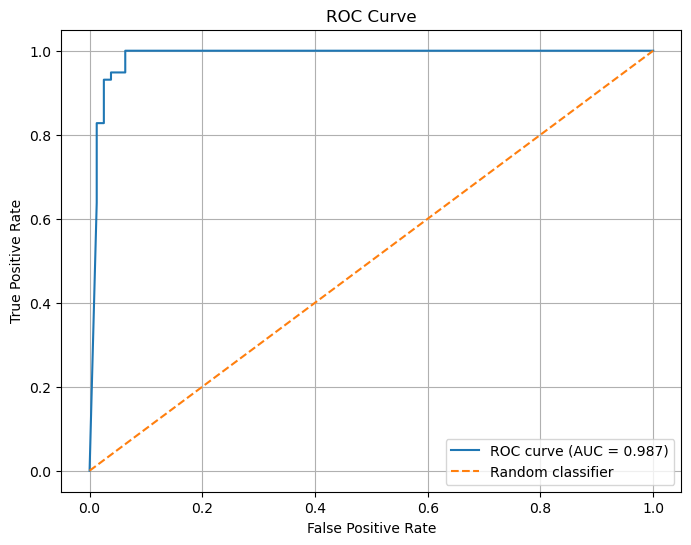

In [11]:
plotting_roc(copy_best_knn_model)

In [27]:
(confusion_matrix(Y_test, y_pred_knn))
# z jednej strony ten wynik wyglada zdrowo, ale z drugiej krzywa ROC jest podejrzana
# ze wzgledu na bardzo maly Dataset te wyniki moga sie wydawac bardzo dobre, ale nie ufalbym im w tym stopniu.

array([[77,  2],
       [ 4, 54]])

Accuracy: 0.927007299270073
F1-score: 0.9074074074074074
ROC AUC: 0.9160846791793977


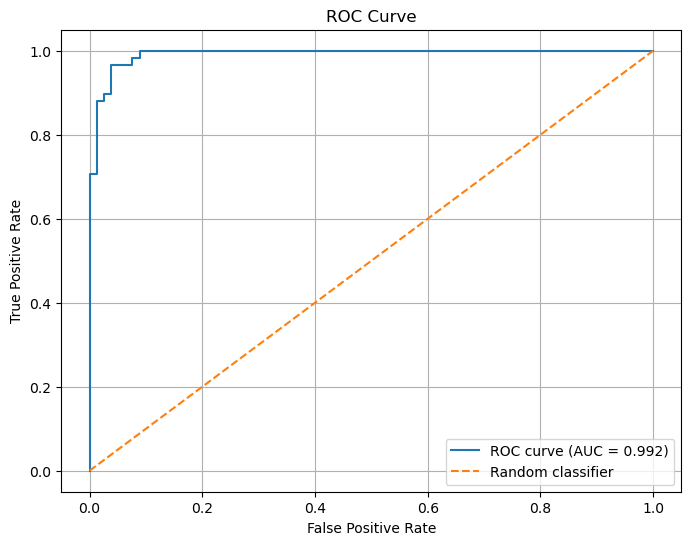

In [14]:
best_lr_model = Pipeline([
        ('scaler', StandardScaler()), # skaluje cechy do sredniej = 0 i odchylenia_stand = 1
        ("kbest", SelectKBest(score_func=f_classif, k=best_knn_params["n_features"])),
        ('model', LogisticRegression(
        C=best_lr_params["C"],
        penalty=best_lr_params["penalty"],
        solver = "liblinear" if best_lr_params["penalty"] == "l1" else "lbfgs",
        max_iter=200
        ))
    ])
copy_best_lr_model = copy.deepcopy(best_lr_model)

best_lr_model.fit(X_train, Y_train)
y_pred_lr = best_lr_model.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, y_pred_lr))
print("F1-score:", f1_score(Y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(Y_test, y_pred_lr))


plotting_roc(copy_best_lr_model)

In [26]:
(confusion_matrix(Y_test, y_pred_lr))

array([[78,  1],
       [ 9, 49]])